<a href="https://colab.research.google.com/github/Uday-1402/ML_Learn/blob/main/end_to_end_toy_proj_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('/content/placement.csv')

In [3]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


# Steps
0. Preprocess + EDA + Feature Selection
1. Extract inpupt and output cell
2. Scale the values
3. Train test split
4. Train the model
5. Evaluate the model/mode selection
6. Deploy the model

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [6]:
# Preprocess
df = df.iloc[:,1:] # Give me all the rows, columns from 1 onwards [:,1:]

In [7]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


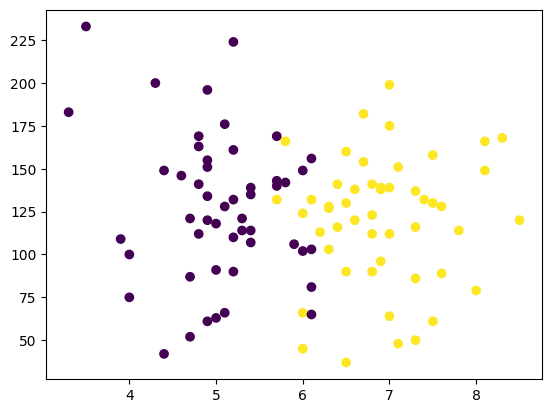

In [11]:
#EDA
import matplotlib.pyplot as plt
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [12]:
# (A line can divide the set) so Linear Regression is a suitable algorithm.

In [14]:
# Step 1
X = df.iloc[:,0:2] #independent columns
Y = df.iloc[:,-1] #placement = depends on the other columns. -1 means first from back i.e. last

In [15]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [16]:
Y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [17]:
Y.shape

(100,)

In [18]:
X.shape

(100, 2)

In [21]:
# Step 3
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.1) # => test_size = 0.1 means 10 percent is test set and 90% is training set.

In [22]:
x_train

,cgpa,iq
60,6.9,139.0
9,5.1,66.0
29,7.0,112.0
98,6.3,103.0
1,5.9,106.0
...,...,...
54,6.4,141.0
3,7.4,132.0
39,4.6,146.0
57,6.5,130.0


In [23]:
x_test

,cgpa,iq
92,5.2,110.0
2,5.3,121.0
52,7.0,175.0
37,8.1,149.0
65,8.1,166.0
88,4.4,149.0
64,7.0,64.0
51,4.8,141.0
17,3.3,183.0
97,6.7,182.0


In [25]:
# Step 2
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [26]:
x_train = scaler.fit_transform(x_train)

In [27]:
x_train

array([[ 0.83846691,  0.44726485],
       [-0.82206658, -1.39854548],
       [ 0.93071877, -0.23543212],
       [ 0.28495575, -0.46299778],
       [-0.0840517 , -0.38714256],
       [-1.92908891, -0.31128734],
       [-1.19107402, -0.00786647],
       [ 0.10045203,  0.87711109],
       [-0.545311  ,  0.44726485],
       [-0.63756286, -0.18486198],
       [-0.72981472,  2.59649605],
       [ 1.39197808, -1.52497085],
       [ 0.10045203, -1.01926939],
       [ 0.83846691, -0.63999329],
       [-1.0065703 , -1.52497085],
       [ 1.66873366, -0.18486198],
       [-0.545311  ,  0.34612455],
       [-0.72981472,  1.00353645],
       [-0.17630356,  0.52312007],
       [ 0.00820017,  0.06798875],
       [-1.56008147,  1.9896543 ],
       [ 0.37720761, -0.13429183],
       [ 0.00820017, -1.39854548],
       [-0.91431844, -0.08372169],
       [ 0.00820017, -0.48828285],
       [ 0.00820017, -1.92953201],
       [ 1.85323738, -1.06983953],
       [ 0.56171133, -0.03315154],
       [-0.545311  ,

In [28]:
x_test = scaler.transform(x_test)

In [29]:
x_test

array([[-0.72981472, -0.28600227],
       [-0.63756286, -0.00786647],
       [ 0.93071877,  1.35752747],
       [ 1.94548924,  0.70011558],
       [ 1.94548924,  1.12996182],
       [-1.46782961,  0.70011558],
       [ 0.93071877, -1.44911563],
       [-1.09882216,  0.49783499],
       [-2.48260007,  1.55980806],
       [ 0.65396319,  1.53452298]])

In [30]:
# Step 4
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()

In [31]:
clf.fit(x_train,y_train) #model training

LogisticRegression()

In [36]:
# Step 5 Evaluation
y_prediction = clf.predict(x_test)
y_prediction

array([0, 0, 1, 1, 1, 0, 1, 0, 0, 1])

In [37]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_prediction)

1.0

In [38]:
# To visualise what pattern was noticed in the data by ML model we can use"mlxtend" library
from mlxtend.plotting import plot_decision_regions

<Axes: >

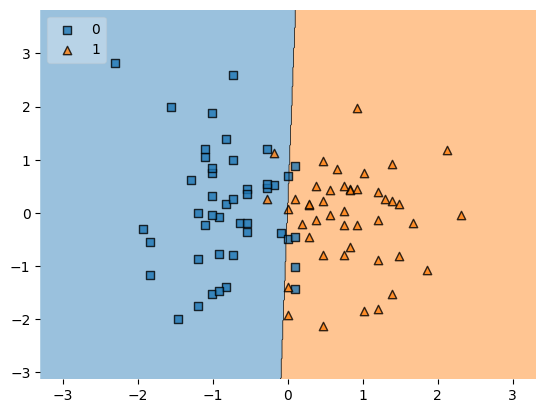

In [39]:
# Plotting decision regions
plot_decision_regions(x_train, y_train.values, clf=clf, legend=2)

In [40]:
import pickle

In [41]:
#converts any object in python into file
pickle.dump(clf,open('model.pkl','wb'))

In [ ]:
# A file called model.pkl is created which contains the model in binary format (due to 'wb') now.